<h1 style="color:rgb(199, 12, 77);">Bitcoin Historical Data - Exploratory Data Analysis</h1>

<h2 style="color:rgb(247, 147, 26)">Notebook Objective</h2> 

Exploring Bitcoin market patterns, trends, volume behavior, and statistical relationships between variables.

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [9]:
df = pd.read_csv(
    "../data/processed/bitcoin_processed.csv",
    parse_dates=["Date"]
)

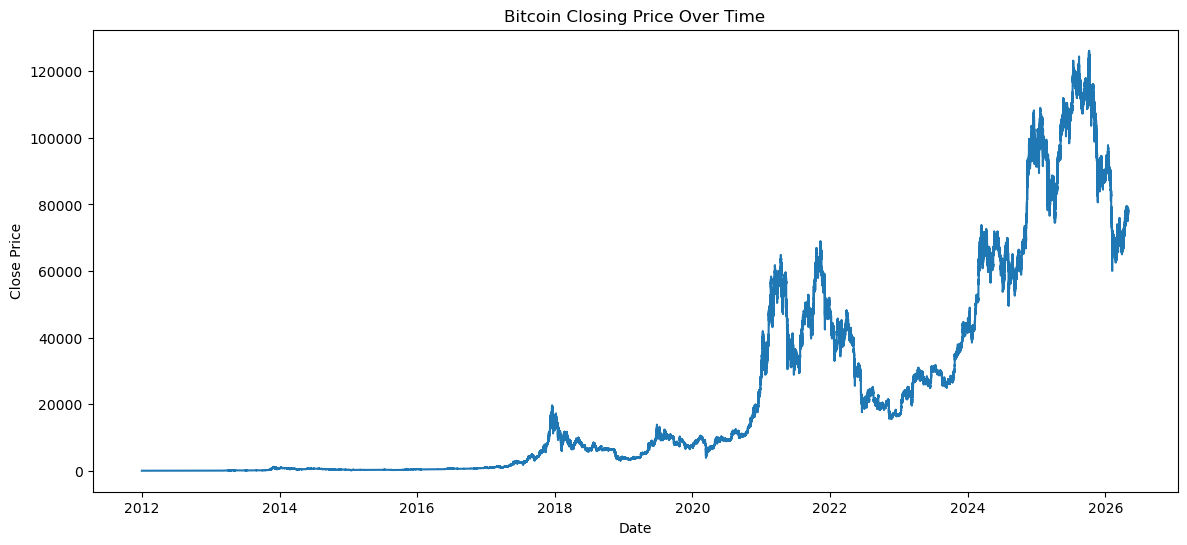

In [12]:
plt.figure(figsize=(14, 6))
plt.plot(df["Date"], df["Close"])
plt.title("Bitcoin Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.savefig("../outputs/figures/notebook1_figures/bitcoin_price_trend.png",dpi=300,
    bbox_inches="tight")
plt.show()

> <h3 style="color:rgb(247, 147, 26)">Bitcoin Price Trend</h3>

> The time-series visualization clearly demonstrates the long-term upward trend and volatility of Bitcoin prices over the years.

> Large price fluctuations and rapid market growth can be observed throughout different market cycles.

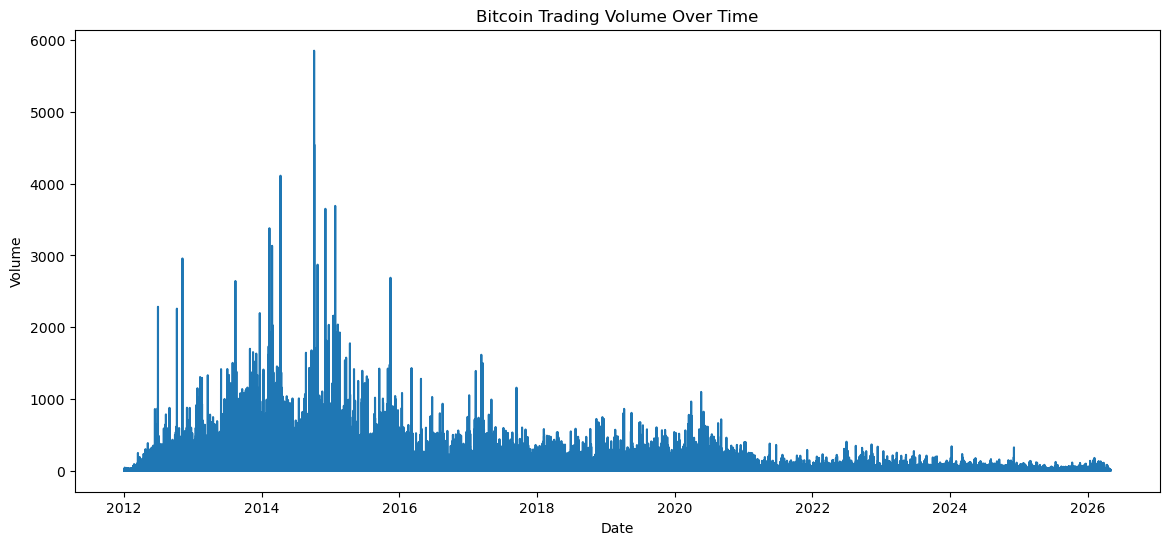

In [14]:
plt.figure(figsize=(14,6))
plt.plot(df["Date"],df["Volume"])
plt.title("Bitcoin Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.savefig("../outputs/figures/notebook1_figures/Bitcoin Trading Volume Over Time.png",dpi=300,
    bbox_inches="tight")
plt.show()

> <h3 style="color:rgb(247, 147, 26)">Trading Volume Analysis</h3>

> The Volume column represents the amount of Bitcoin traded during each 1-minute interval. 

> Periods of high trading volume may indicate increased market activity, stronger momentum, and higher investor participation.

In [13]:
df.head()

,Timestamp,Open,High,Low,Close,Volume,Date
0,1.325412e+09,4.58,4.58,4.58,4.58,0.0,2012-01-01 10:01:00
1,1.325412e+09,4.58,4.58,4.58,4.58,0.0,2012-01-01 10:02:00
2,1.325412e+09,4.58,4.58,4.58,4.58,0.0,2012-01-01 10:03:00
3,1.325412e+09,4.58,4.58,4.58,4.58,0.0,2012-01-01 10:04:00
4,1.325412e+09,4.58,4.58,4.58,4.58,0.0,2012-01-01 10:05:00


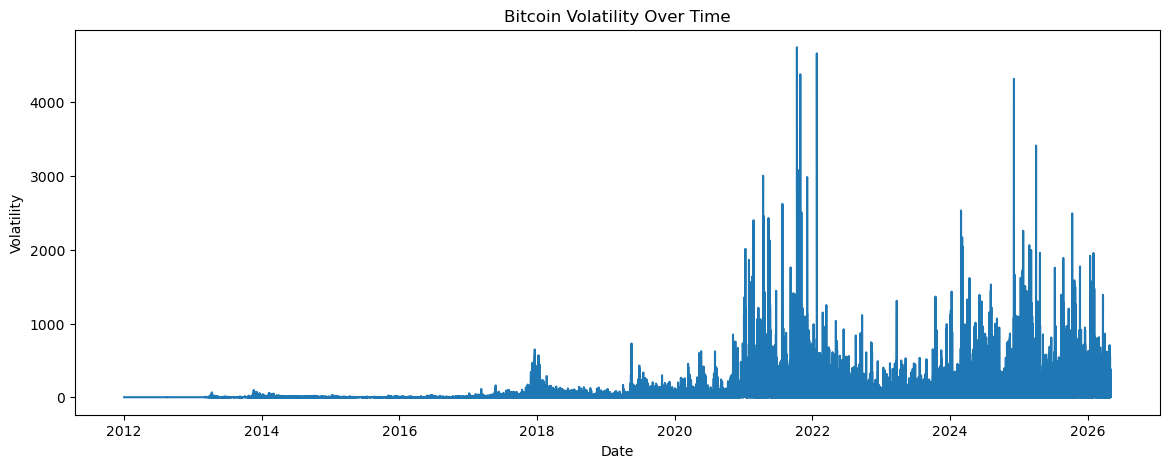

In [35]:
df["Volatility"] = df["High"] - df["Low"]

plt.figure(figsize=(14,5))
plt.plot(df["Date"],df["Volatility"])
plt.title("Bitcoin Volatility Over Time")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.show()

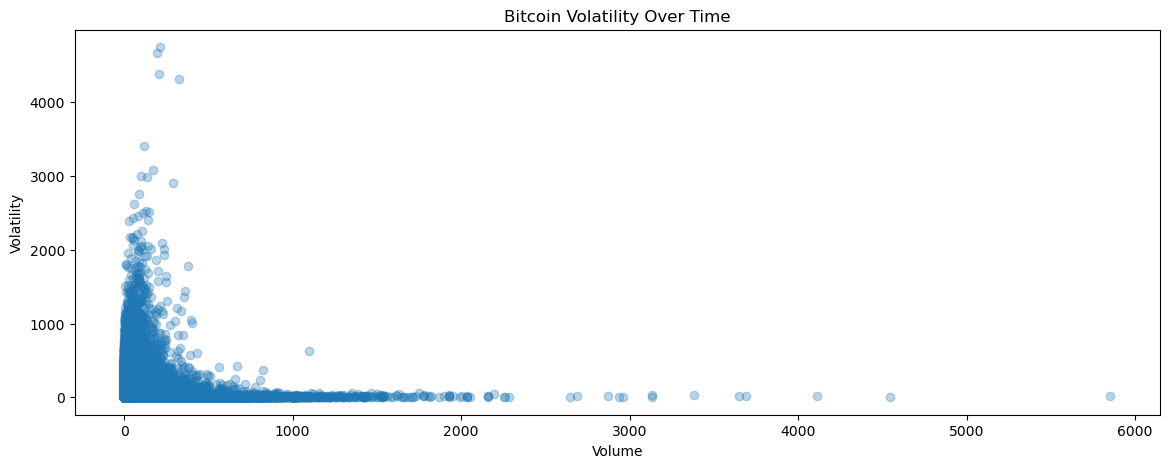

In [44]:
plt.figure(figsize=(14,5))

plt.scatter(df["Volume"],df["Volatility"], alpha=0.3)

plt.title("Bitcoin Volatility Over Time")
plt.xlabel("Volume")
plt.ylabel("Volatility")

plt.show()

The relationship between trading volume and volatility appears highly non-linear.  
Most observations are concentrated in low-volume and low-volatility regions, while extreme volatility spikes occur less frequently and may represent periods of sudden market instability.

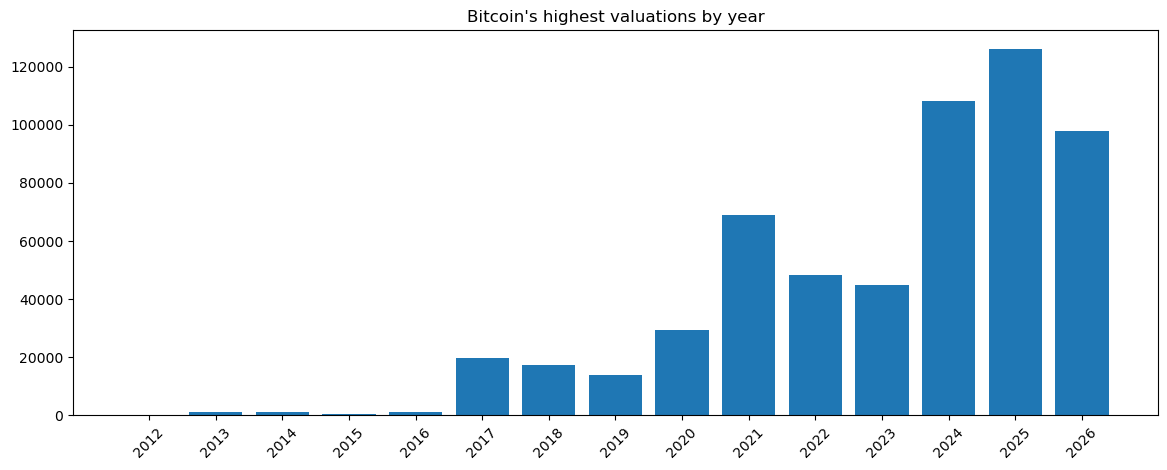

In [54]:
df["Year"] = df["Date"].dt.year

max_values = df.groupby("Year")["Close"].max()
 
plt.figure(figsize=(14,5))

plt.bar(max_values.index,max_values.values)

plt.xticks(max_values.index, rotation=45)

plt.title("Bitcoin's highest valuations by year")

plt.show()

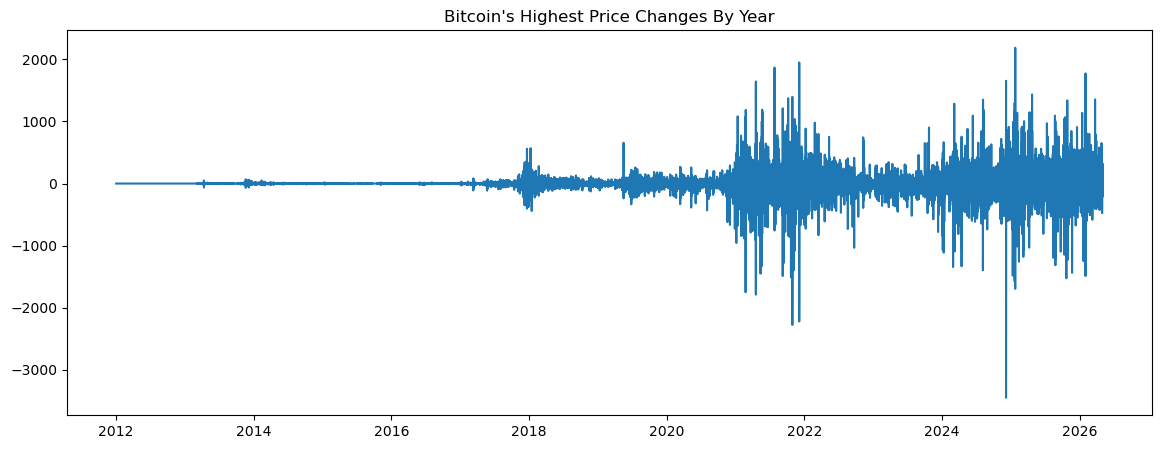

In [60]:
df["Price_change"] = df["Close"] - df["Open"]
 
plt.figure(figsize=(14,5))

plt.plot(df["Date"],df["Price_change"])

plt.title("Bitcoin's Highest Price Changes By Year")

plt.show()

In [76]:
df["Return"] = (df["Close"] - df["Open"])/df["Open"]

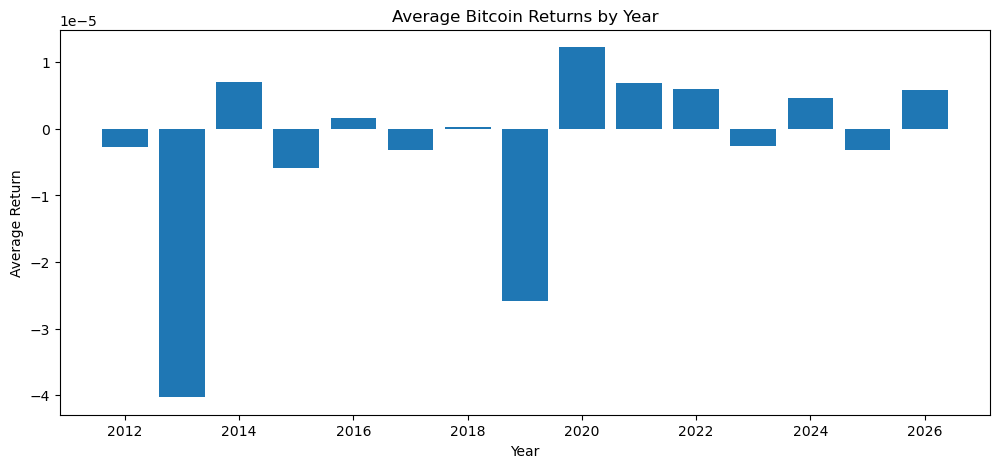

In [79]:
yearly_returns = df.groupby("Year")["Return"].mean()

plt.figure(figsize=(12,5))

plt.bar(yearly_returns.index, yearly_returns.values)

plt.title("Average Bitcoin Returns by Year")
plt.xlabel("Year")
plt.ylabel("Average Return")

plt.show()

In [83]:
df["MA_60"] = df["Close"].rolling(window=60).mean()
df["MA_240"] = df["Close"].rolling(window=240).mean()
df["MA_1440"] = df["Close"].rolling(window=1440).mean()

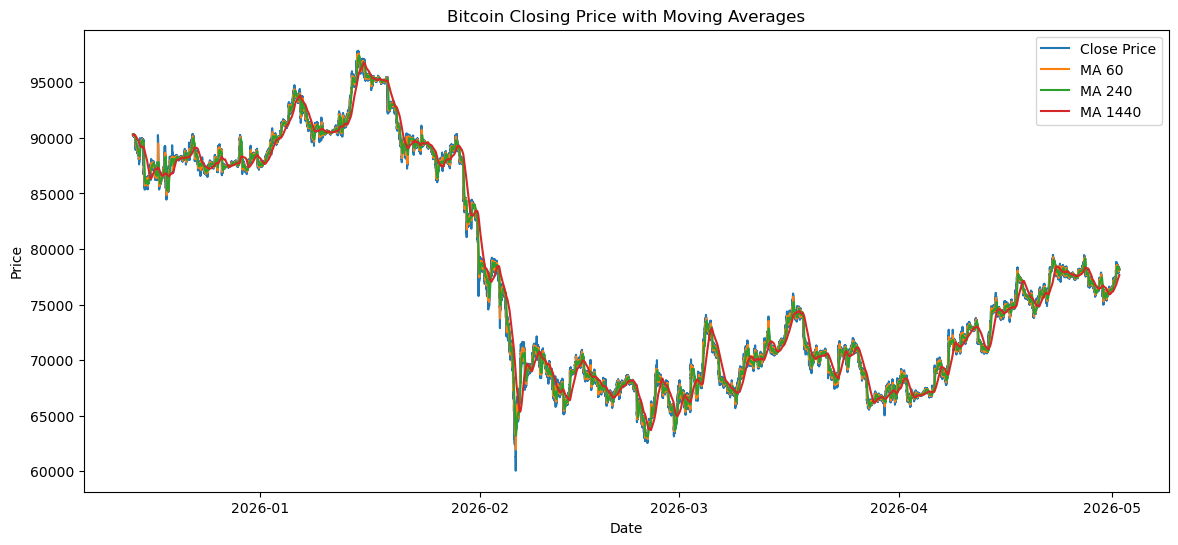

In [91]:
sample_df = df.tail(200000)

plt.figure(figsize=(14,6))

plt.plot(sample_df["Date"], sample_df["Close"], label="Close Price")
plt.plot(sample_df["Date"], sample_df["MA_60"], label="MA 60")
plt.plot(sample_df["Date"], sample_df["MA_240"], label="MA 240")
plt.plot(sample_df["Date"], sample_df["MA_1440"], label="MA 1440")

plt.title("Bitcoin Closing Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

In [93]:
df["Rolling_Volatility"] = df["Return"].rolling(window=60).std()

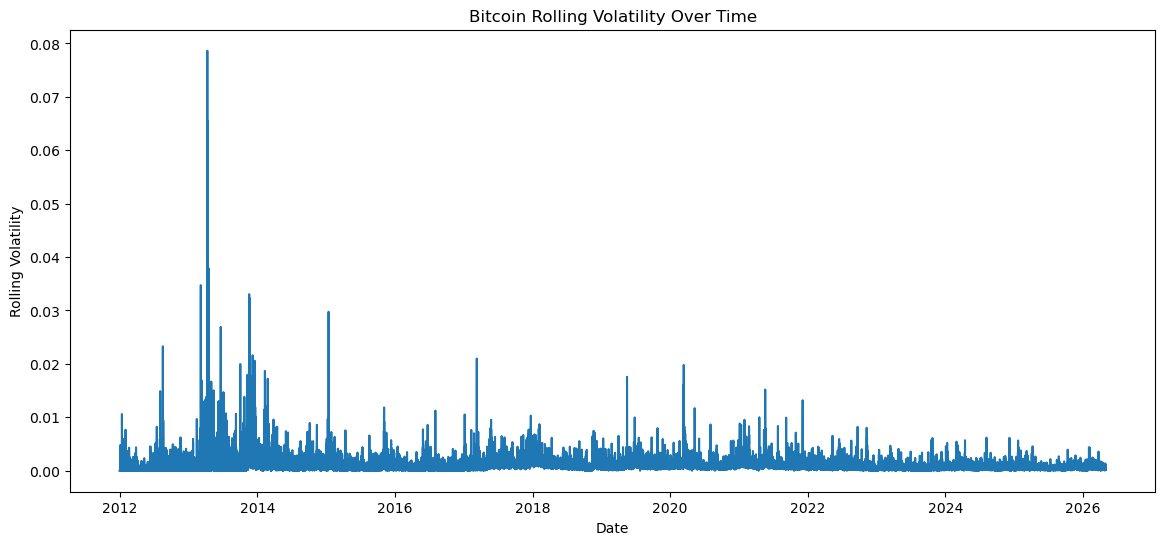

In [95]:
plt.figure(figsize=(14,6))
plt.plot(df["Date"],df["Rolling_Volatility"])

plt.title("Bitcoin Rolling Volatility Over Time")
plt.xlabel("Date")
plt.ylabel("Rolling Volatility")

plt.show()

In [102]:
correlation_matrix = df[["Open","High","Low","Close","Volume","Volatility","Price_change","Rolling_Volatility"]].corr()

correlation_matrix

,Open,High,Low,Close,Volume,Volatility,Price_change,Rolling_Volatility
Open,1.000000,1.000000,1.000000,1.000000,-0.095696,0.479363,0.000435,-0.172217
High,1.000000,1.000000,1.000000,1.000000,-0.095639,0.479785,0.000891,-0.172113
Low,1.000000,1.000000,1.000000,1.000000,-0.095762,0.478911,0.000901,-0.172324
Close,1.000000,1.000000,1.000000,1.000000,-0.095701,0.479354,0.001315,-0.172216
Volume,-0.095696,-0.095639,-0.095762,-0.095701,1.000000,0.062649,-0.005806,0.239716
Volatility,0.479363,0.479785,0.478911,0.479354,0.062649,1.000000,-0.009139,0.102980
Price_change,0.000435,0.000891,0.000901,0.001315,-0.005806,-0.009139,1.000000,0.000723
Rolling_Volatility,-0.172217,-0.172113,-0.172324,-0.172216,0.239716,0.102980,0.000723,1.000000


In [103]:
df.head()

,Timestamp,Open,High,Low,Close,Volume,Date,Volatility,Year,Price_change,Return,MA_60,MA_240,MA_1440,Rolling_Volatility
0,1.325412e+09,4.58,4.58,4.58,4.58,0.0,2012-01-01 10:01:00,0.0,2012,0.0,0.0,NaN,NaN,NaN,NaN
1,1.325412e+09,4.58,4.58,4.58,4.58,0.0,2012-01-01 10:02:00,0.0,2012,0.0,0.0,NaN,NaN,NaN,NaN
2,1.325412e+09,4.58,4.58,4.58,4.58,0.0,2012-01-01 10:03:00,0.0,2012,0.0,0.0,NaN,NaN,NaN,NaN
3,1.325412e+09,4.58,4.58,4.58,4.58,0.0,2012-01-01 10:04:00,0.0,2012,0.0,0.0,NaN,NaN,NaN,NaN
4,1.325412e+09,4.58,4.58,4.58,4.58,0.0,2012-01-01 10:05:00,0.0,2012,0.0,0.0,NaN,NaN,NaN,NaN


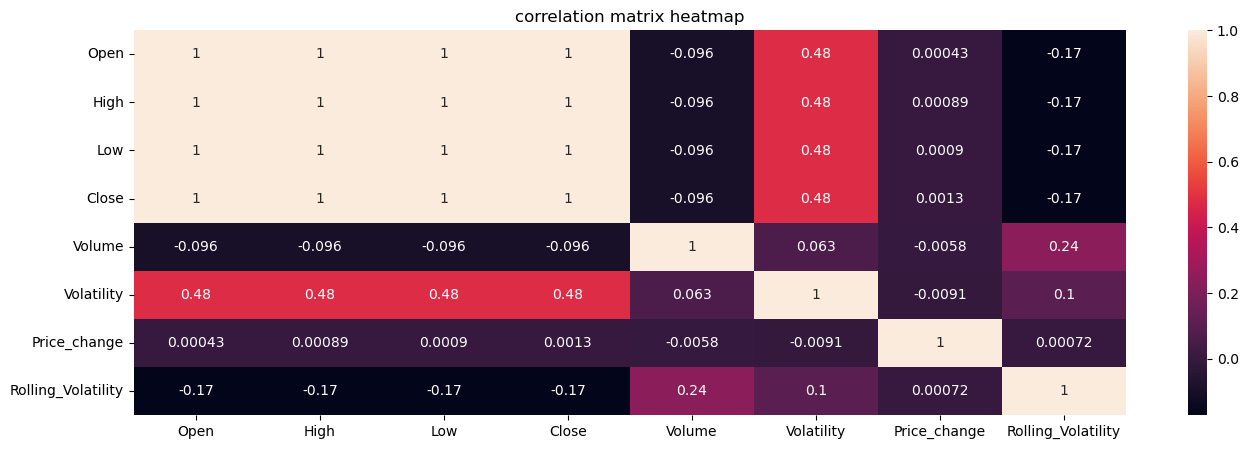

In [107]:
plt.figure(figsize=(16,5))
sns.heatmap(correlation_matrix,annot=True)
plt.title("correlation matrix heatmap")
plt.show()

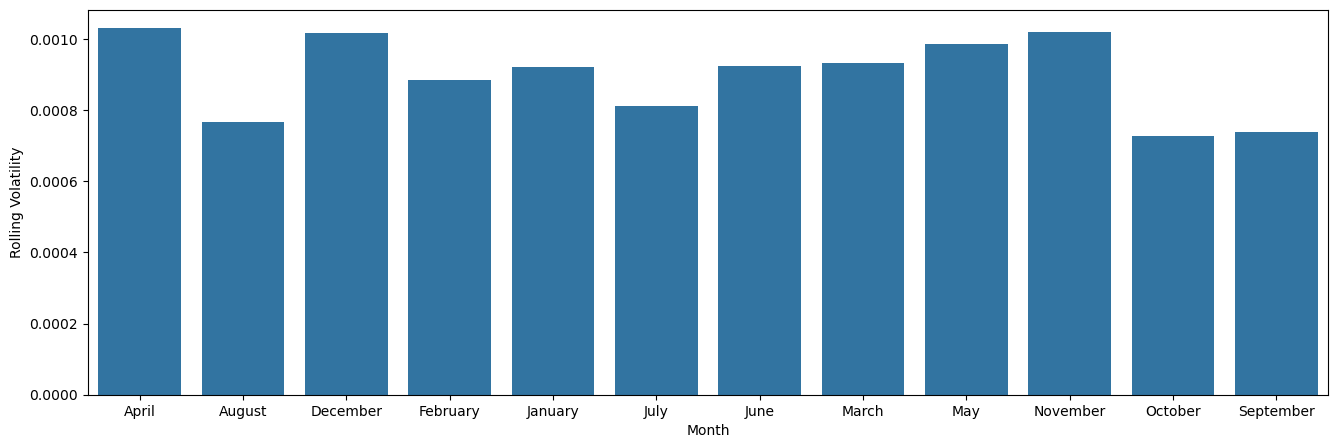

In [117]:
df["Month"] = df["Date"].dt.month_name()

monthly_change = df.groupby("Month")["Rolling_Volatility"].mean()

plt.figure(figsize=(16,5))
sns.barplot(x=monthly_change.index,y=monthly_change.values)
plt.xlabel("Month")
plt.ylabel("Rolling Volatility")
plt.show()

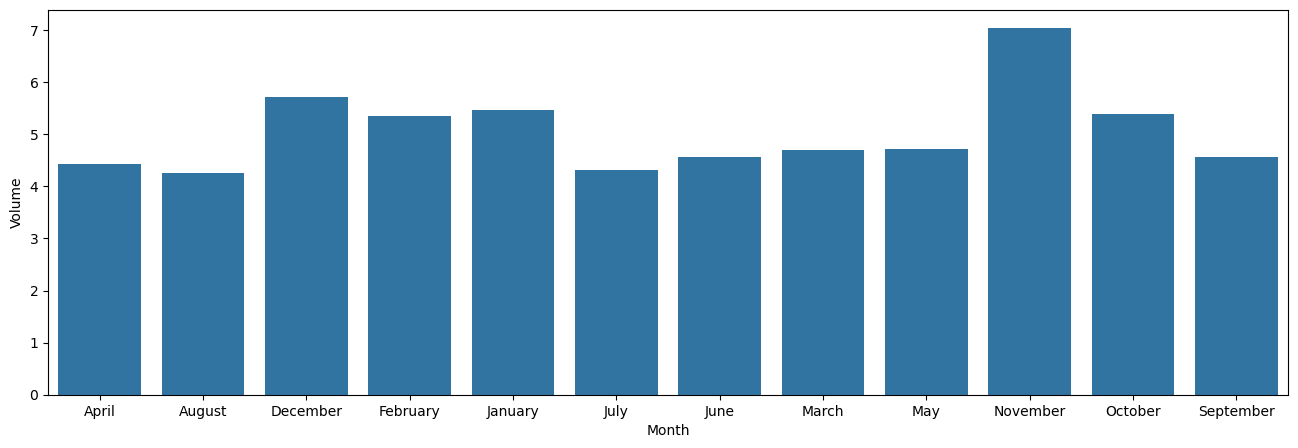

In [119]:
monthly_change = df.groupby("Month")["Volume"].mean()

plt.figure(figsize=(16,5))
sns.barplot(x=monthly_change.index,y=monthly_change.values)
plt.xlabel("Month")
plt.ylabel("Volume")
plt.show()

,Timestamp,Open,High,Low,Close,Volume,Date,Volatility,Year,Price_change,Return,MA_60,MA_240,MA_1440,Rolling_Volatility,Month
0,1.325412e+09,4.58,4.58,4.58,4.58,0.0,2012-01-01 10:01:00,0.0,2012,0.0,0.0,NaN,NaN,NaN,NaN,January
1,1.325412e+09,4.58,4.58,4.58,4.58,0.0,2012-01-01 10:02:00,0.0,2012,0.0,0.0,NaN,NaN,NaN,NaN,January
2,1.325412e+09,4.58,4.58,4.58,4.58,0.0,2012-01-01 10:03:00,0.0,2012,0.0,0.0,NaN,NaN,NaN,NaN,January
3,1.325412e+09,4.58,4.58,4.58,4.58,0.0,2012-01-01 10:04:00,0.0,2012,0.0,0.0,NaN,NaN,NaN,NaN,January
4,1.325412e+09,4.58,4.58,4.58,4.58,0.0,2012-01-01 10:05:00,0.0,2012,0.0,0.0,NaN,NaN,NaN,NaN,January
